# Mixed Workload Analysis Entrypoint

Use this notebook to inspect sweep outputs, regenerate quick plots, and draft findings for `docs/results.md`.

In [9]:
from __future__ import annotations

import csv
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

BASELINE = ROOT / 'results' / 'sweep.csv'
CONTENTION = ROOT / 'results' / 'high_contention_sweep.csv'

print('Root:', ROOT)
print('Baseline CSV exists:', BASELINE.exists())
print('High-contention CSV exists:', CONTENTION.exists())

Root: /Users/aaliyan/aaliyan/mixed-workload-serving-benchmark
Baseline CSV exists: True
High-contention CSV exists: True


In [10]:
def load_rows(path: Path) -> list[dict[str, float | str]]:
    rows: list[dict[str, float | str]] = []
    with path.open(newline='') as fp:
        reader = csv.DictReader(fp)
        for raw in reader:
            rows.append({
                'policy': raw['policy'],
                'streaming_ratio': float(raw['streaming_ratio']),
                'agentic_ratio': float(raw['agentic_ratio']),
                'throughput_rps': float(raw['throughput_rps']),
                'throughput_rps_ci95': float(raw.get('throughput_rps_ci95', 0.0)),
                'p95_latency_ms': float(raw['p95_latency_ms']),
                'p95_latency_ms_ci95': float(raw.get('p95_latency_ms_ci95', 0.0)),
                'sla_violation_rate': float(raw['sla_violation_rate']),
                'sla_violation_rate_ci95': float(raw.get('sla_violation_rate_ci95', 0.0)),
                'cost_per_success': float(raw['cost_per_success']),
                'cost_per_success_ci95': float(raw.get('cost_per_success_ci95', 0.0)),
            })
    return rows

baseline_rows = load_rows(BASELINE)
contention_rows = load_rows(CONTENTION)

print('Baseline rows:', len(baseline_rows))
print('High-contention rows:', len(contention_rows))

Baseline rows: 9
High-contention rows: 9


In [11]:
def best_policy(rows: list[dict[str, float | str]], metric: str, direction: str) -> str:
    if direction == 'higher':
        row = max(rows, key=lambda r: float(r[metric]))
    else:
        row = min(rows, key=lambda r: float(r[metric]))
    return str(row['policy'])

metrics = [
    ('throughput_rps', 'higher'),
    ('p95_latency_ms', 'lower'),
    ('sla_violation_rate', 'lower'),
    ('cost_per_success', 'lower'),
]

print('Baseline winners')
for key, direction in metrics:
    print(f'  {key}: {best_policy(baseline_rows, key, direction)}')

print('\nHigh-contention winners')
for key, direction in metrics:
    print(f'  {key}: {best_policy(contention_rows, key, direction)}')

Baseline winners
  throughput_rps: fifo
  p95_latency_ms: shortest-job-first
  sla_violation_rate: shortest-job-first
  cost_per_success: fifo

High-contention winners
  throughput_rps: shortest-job-first
  p95_latency_ms: shortest-job-first
  sla_violation_rate: shortest-job-first
  cost_per_success: shortest-job-first


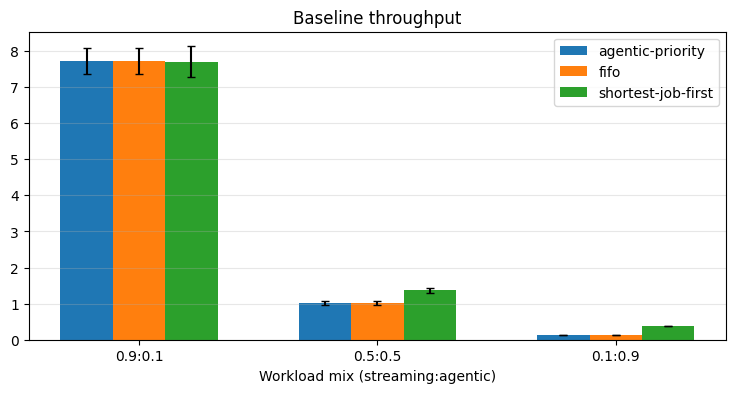

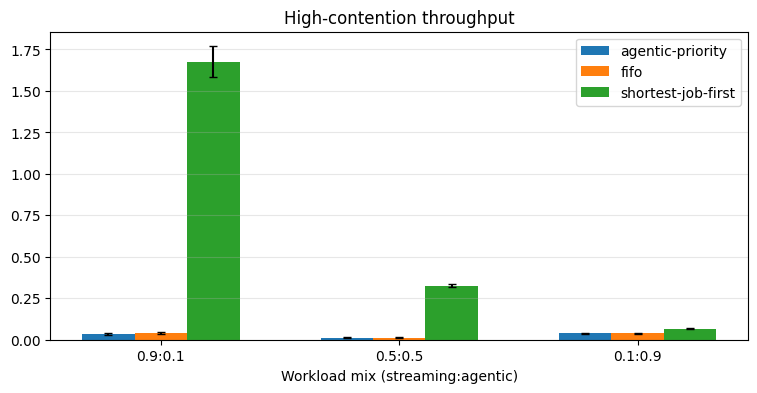

In [12]:
def plot_metric(rows: list[dict[str, float | str]], metric: str, ci_metric: str, title: str) -> None:
    policies = sorted({str(r['policy']) for r in rows})
    mixes = sorted({float(r['streaming_ratio']) for r in rows}, reverse=True)

    width = 0.22
    x = list(range(len(mixes)))

    fig, ax = plt.subplots(figsize=(9, 4))
    for i, policy in enumerate(policies):
        ys = []
        errs = []
        for mix in mixes:
            row = next(r for r in rows if r['policy'] == policy and r['streaming_ratio'] == mix)
            ys.append(float(row[metric]))
            errs.append(float(row[ci_metric]))
        offset = [v + (i - (len(policies) - 1) / 2) * width for v in x]
        ax.bar(offset, ys, width=width, yerr=errs, capsize=3, label=policy)

    labels = [f'{m:.1f}:{1.0 - m:.1f}' for m in mixes]
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel('Workload mix (streaming:agentic)')
    ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.show()

plot_metric(baseline_rows, 'throughput_rps', 'throughput_rps_ci95', 'Baseline throughput')
plot_metric(contention_rows, 'throughput_rps', 'throughput_rps_ci95', 'High-contention throughput')

## Findings Draft Prompts

Use these prompts to write your short report:

- Which policy dominates in baseline vs high-contention?
- Where does tail latency degrade fastest as agentic ratio rises?
- How do SLA violations track with cost-per-success under contention?
- What deployment recommendation follows for mixed traffic systems?

Then transfer your polished text into `docs/results.md` and `docs/technical_note_template.md`.

## Live Trace Analysis (Ollama)

This section consumes request-level JSONL traces generated with:

`uv run mws-bench run --config configs/live_ollama.json --output results/live_ollama_run.json --trace-output results/live_ollama_trace.jsonl`

If no trace file exists, the cells below will skip gracefully.

In [13]:
import json

TRACE_PATH = ROOT / 'results' / 'live_ollama_trace.jsonl'

def load_trace_rows(path: Path) -> list[dict[str, float | int | str | bool | None]]:
    rows: list[dict[str, float | int | str | bool | None]] = []
    if not path.exists():
        return rows
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        rows.append(json.loads(line))
    return rows

trace_rows = load_trace_rows(TRACE_PATH)
print('Trace path:', TRACE_PATH)
print('Trace exists:', TRACE_PATH.exists())
print('Trace rows:', len(trace_rows))

Trace path: /Users/aaliyan/aaliyan/mixed-workload-serving-benchmark/results/live_ollama_trace.jsonl
Trace exists: True
Trace rows: 10


In [14]:
def summarize_trace(rows: list[dict[str, float | int | str | bool | None]]) -> None:
    if not rows:
        print('No trace data available.')
        return

    total = len(rows)
    timeout_count = sum(1 for r in rows if bool(r.get('timed_out')))

    by_type: dict[str, list[float]] = {}
    by_status: dict[str, int] = {}
    for row in rows:
        job_type = str(row.get('job_type', 'unknown'))
        latency = float(row.get('latency_ms', 0.0))
        by_type.setdefault(job_type, []).append(latency)

        status = str(row.get('backend_status', 'unknown'))
        by_status[status] = by_status.get(status, 0) + 1

    print('Total requests:', total)
    print('Timeout count:', timeout_count)
    print('Timeout rate:', round(timeout_count / total, 4) if total else 0.0)
    print('\nLatency by job type (mean/p95 ms):')
    for job_type in sorted(by_type):
        latencies = sorted(by_type[job_type])
        mean = sum(latencies) / len(latencies)
        p95_idx = max(int(0.95 * (len(latencies) - 1)), 0)
        p95 = latencies[p95_idx]
        print(f'  {job_type}: mean={mean:.2f}, p95={p95:.2f}, n={len(latencies)}')

    print('\nBackend status counts:')
    for status in sorted(by_status):
        print(f'  {status}: {by_status[status]}')

summarize_trace(trace_rows)

Total requests: 10
Timeout count: 0
Timeout rate: 0.0

Latency by job type (mean/p95 ms):
  agentic: mean=8941.14, p95=7125.99, n=2
  streaming: mean=6942.04, p95=10990.95, n=8

Backend status counts:
  ok: 10


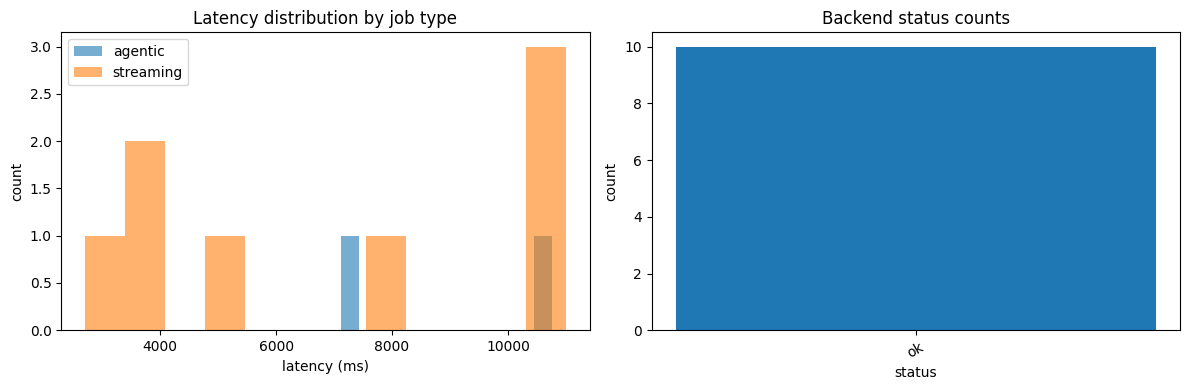

In [15]:
def plot_trace_latency(rows: list[dict[str, float | int | str | bool | None]]) -> None:
    if not rows:
        print('No trace data available.')
        return

    by_type: dict[str, list[float]] = {}
    status_counts: dict[str, int] = {}

    for row in rows:
        job_type = str(row.get('job_type', 'unknown'))
        by_type.setdefault(job_type, []).append(float(row.get('latency_ms', 0.0)))

        status = str(row.get('backend_status', 'unknown'))
        status_counts[status] = status_counts.get(status, 0) + 1

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for job_type, latencies in sorted(by_type.items()):
        axes[0].hist(latencies, bins=12, alpha=0.6, label=job_type)
    axes[0].set_title('Latency distribution by job type')
    axes[0].set_xlabel('latency (ms)')
    axes[0].set_ylabel('count')
    axes[0].legend()

    labels = sorted(status_counts)
    values = [status_counts[label] for label in labels]
    axes[1].bar(labels, values)
    axes[1].set_title('Backend status counts')
    axes[1].set_xlabel('status')
    axes[1].set_ylabel('count')
    axes[1].tick_params(axis='x', rotation=30)

    fig.tight_layout()
    plt.show()

plot_trace_latency(trace_rows)

## Pareto Frontier (Decision Support)

This section identifies non-dominated policy+mix points using:

- maximize `throughput_rps`
- minimize `sla_violation_rate`

A point is on the Pareto frontier if no other point has **higher or equal throughput** and **lower or equal SLA violation**, with at least one strict improvement.

In [16]:
def pareto_frontier(rows: list[dict[str, float | str]]) -> list[dict[str, float | str]]:
    frontier: list[dict[str, float | str]] = []

    for candidate in rows:
        c_t = float(candidate['throughput_rps'])
        c_s = float(candidate['sla_violation_rate'])
        dominated = False

        for other in rows:
            if other is candidate:
                continue
            o_t = float(other['throughput_rps'])
            o_s = float(other['sla_violation_rate'])
            if (o_t >= c_t and o_s <= c_s) and (o_t > c_t or o_s < c_s):
                dominated = True
                break

        if not dominated:
            frontier.append(candidate)

    return sorted(frontier, key=lambda r: (float(r['sla_violation_rate']), -float(r['throughput_rps'])))


def print_frontier(name: str, rows: list[dict[str, float | str]]) -> None:
    frontier = pareto_frontier(rows)
    print(name)
    if not frontier:
        print('  No rows available')
        return

    for r in frontier:
        policy = str(r['policy'])
        s = float(r['streaming_ratio'])
        a = float(r['agentic_ratio'])
        t = float(r['throughput_rps'])
        v = float(r['sla_violation_rate'])
        print(f'  {policy:20s} mix={s:.1f}:{a:.1f} throughput={t:.4f} sla={v:.4f}')


print_frontier('Baseline frontier:', baseline_rows)
print()
print_frontier('High-contention frontier:', contention_rows)

Baseline frontier:
  shortest-job-first   mix=0.9:0.1 throughput=7.7048 sla=0.0272
  fifo                 mix=0.9:0.1 throughput=7.7209 sla=0.0275
  agentic-priority     mix=0.9:0.1 throughput=7.7209 sla=0.0275

High-contention frontier:
  shortest-job-first   mix=0.9:0.1 throughput=1.6760 sla=0.5031


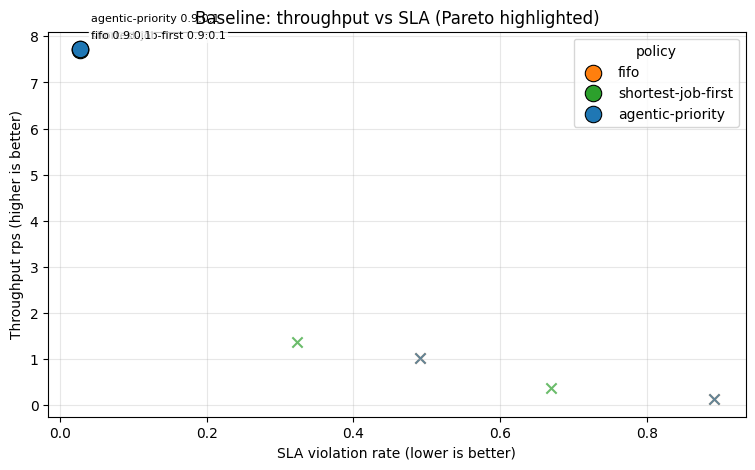

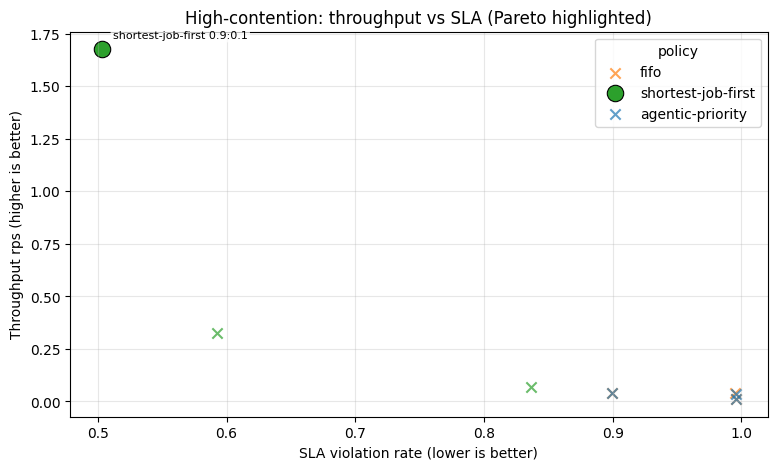

In [18]:
def plot_frontier(name: str, rows: list[dict[str, float | str]]) -> None:
    if not rows:
        print(f'{name}: no rows')
        return

    frontier = pareto_frontier(rows)
    frontier_keys = {
        (str(r['policy']), float(r['streaming_ratio']), float(r['agentic_ratio']))
        for r in frontier
    }

    policies = sorted({str(r['policy']) for r in rows})
    palette = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:brown']
    color_map = {p: palette[i % len(palette)] for i, p in enumerate(policies)}

    fig, ax = plt.subplots(figsize=(9, 5))

    label_used: set[str] = set()
    for r in rows:
        policy = str(r['policy'])
        s = float(r['streaming_ratio'])
        a = float(r['agentic_ratio'])
        t = float(r['throughput_rps'])
        v = float(r['sla_violation_rate'])
        key = (policy, s, a)

        label = policy if policy not in label_used else None
        label_used.add(policy)

        if key in frontier_keys:
            ax.scatter(v, t, s=140, marker='o', color=color_map[policy], edgecolor='black', linewidth=0.8, label=label)
        else:
            ax.scatter(v, t, s=55, marker='x', color=color_map[policy], alpha=0.7, label=label)

    # Annotate only frontier points and offset overlapping labels.
    grouped: dict[tuple[float, float], list[str]] = {}
    for r in frontier:
        policy = str(r['policy'])
        s = float(r['streaming_ratio'])
        a = float(r['agentic_ratio'])
        t = float(r['throughput_rps'])
        v = float(r['sla_violation_rate'])
        grouped.setdefault((v, t), []).append(f"{policy} {s:.1f}:{a:.1f}")

    for (v, t), labels in grouped.items():
        for i, text in enumerate(labels):
            ax.annotate(
                text,
                (v, t),
                textcoords='offset points',
                xytext=(8, 8 + 12 * i),
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.75, ec='none'),
            )

    ax.set_title(f'{name}: throughput vs SLA (Pareto highlighted)')
    ax.set_xlabel('SLA violation rate (lower is better)')
    ax.set_ylabel('Throughput rps (higher is better)')
    ax.grid(alpha=0.3)
    ax.legend(title='policy', loc='best')
    plt.show()


plot_frontier('Baseline', baseline_rows)
plot_frontier('High-contention', contention_rows)

## Queue Wait Analysis Across Live Sweep Traces

This section reads all per-scenario trace files from a live sweep directory and summarizes queue wait behavior across policy and mix.

Default order of directories checked:

1. results/traces/live_ollama_r5
2. results/traces/live_ollama

In [19]:
TRACE_DIR_CANDIDATES = [
    ROOT / 'results' / 'traces' / 'live_ollama_r5',
    ROOT / 'results' / 'traces' / 'live_ollama',
]


def pick_trace_dir(paths: list[Path]) -> Path | None:
    for p in paths:
        if p.exists() and any(p.glob('*.jsonl')):
            return p
    return None


def load_trace_dir(path: Path) -> list[dict[str, float | int | str | bool | None]]:
    rows: list[dict[str, float | int | str | bool | None]] = []
    for file_path in sorted(path.glob('*.jsonl')):
        for line in file_path.read_text().splitlines():
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows

trace_dir = pick_trace_dir(TRACE_DIR_CANDIDATES)
if trace_dir is None:
    print('No live sweep trace directory found.')
    sweep_trace_rows = []
else:
    sweep_trace_rows = load_trace_dir(trace_dir)
    print('Using trace directory:', trace_dir)
    print('Trace files:', len(list(trace_dir.glob('*.jsonl'))))
    print('Trace rows:', len(sweep_trace_rows))

Using trace directory: /Users/aaliyan/aaliyan/mixed-workload-serving-benchmark/results/traces/live_ollama_r5
Trace files: 9
Trace rows: 231


In [20]:
def summarize_queue_wait(rows: list[dict[str, float | int | str | bool | None]]) -> None:
    if not rows:
        print('No sweep trace rows available.')
        return

    grouped: dict[str, list[float]] = {}
    for r in rows:
        policy = str(r['policy'])
        s = float(r['streaming_ratio'])
        a = float(r['agentic_ratio'])
        key = f"{policy} {s:.1f}:{a:.1f}"
        grouped.setdefault(key, []).append(float(r.get('queue_wait_ms', 0.0)))

    print('Queue wait summary by policy/mix (mean, p95, max in ms):')
    for key in sorted(grouped):
        vals = sorted(grouped[key])
        mean = sum(vals) / len(vals)
        p95 = vals[max(int(0.95 * (len(vals) - 1)), 0)]
        mx = vals[-1]
        print(f'  {key:35s} mean={mean:8.2f} p95={p95:8.2f} max={mx:8.2f} n={len(vals)}')


summarize_queue_wait(sweep_trace_rows)

Queue wait summary by policy/mix (mean, p95, max in ms):
  agentic-priority 0.1:0.9            mean= 1507.33 p95= 5407.72 max= 6038.45 n=25
  agentic-priority 0.5:0.5            mean= 1699.76 p95= 5669.08 max= 6587.49 n=25
  agentic-priority 0.9:0.1            mean=  589.32 p95= 1990.20 max= 4409.76 n=27
  fifo 0.1:0.9                        mean= 1780.26 p95= 5910.47 max= 7730.33 n=25
  fifo 0.5:0.5                        mean= 1697.44 p95= 5748.80 max= 6619.35 n=25
  fifo 0.9:0.1                        mean= 1032.43 p95= 3286.45 max= 4223.16 n=27
  shortest-job-first 0.1:0.9          mean= 1482.29 p95= 5108.09 max= 9399.70 n=25
  shortest-job-first 0.5:0.5          mean= 1410.12 p95= 5108.30 max= 9985.78 n=25
  shortest-job-first 0.9:0.1          mean=  518.55 p95= 2694.58 max= 3153.27 n=27


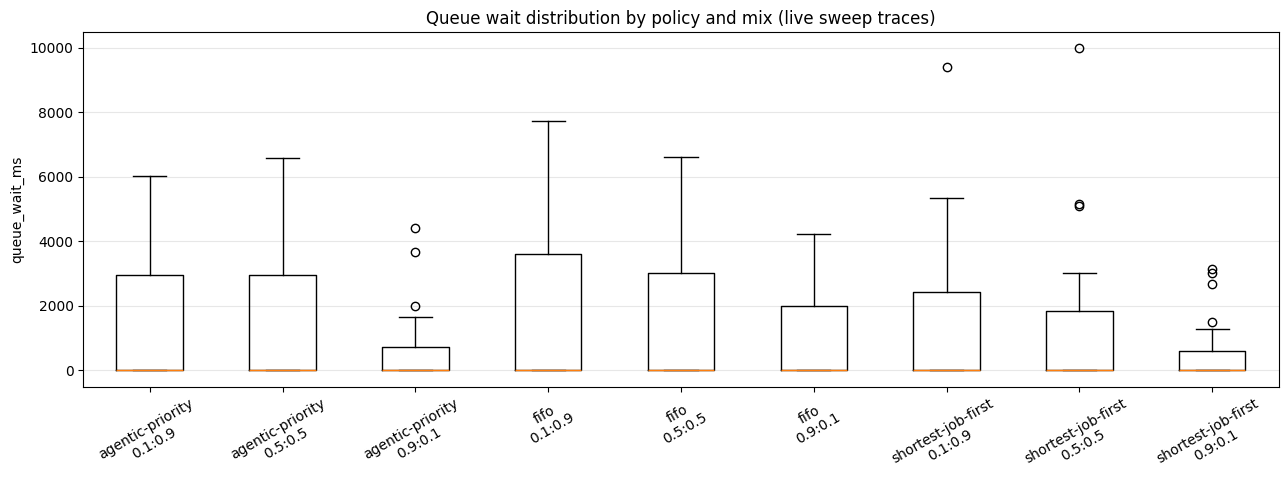

In [22]:
def plot_queue_wait_box(rows: list[dict[str, float | int | str | bool | None]]) -> None:
    if not rows:
        print('No sweep trace rows available.')
        return

    grouped: dict[str, list[float]] = {}
    for r in rows:
        policy = str(r['policy'])
        s = float(r['streaming_ratio'])
        a = float(r['agentic_ratio'])
        key = f"{policy}\n{s:.1f}:{a:.1f}"
        grouped.setdefault(key, []).append(float(r.get('queue_wait_ms', 0.0)))

    labels = sorted(grouped)
    values = [grouped[label] for label in labels]

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.boxplot(values, tick_labels=labels, showfliers=True)
    ax.set_title('Queue wait distribution by policy and mix (live sweep traces)')
    ax.set_ylabel('queue_wait_ms')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    plt.show()


plot_queue_wait_box(sweep_trace_rows)